# Notebook 04 — Classification automatique des transactions

**Objectif**: Entraîner un classifieur TF-IDF + Régression Logistique pour catégoriser  
automatiquement les transactions bancaires.

**Dataset enrichi**: `data/processed/transactions_enriched.csv`  
- Données originales : 46 702 transactions marocaines (Marjane, BIM, Carrefour, Shell…)  
- Données nouvelles  : 10 680 transactions supplémentaires étiquetées automatiquement  
  (H&M, Nike, Zara, Amazon, AliExpress, Jumia, Fnac, Sephora…)  
- **Total** : 57 382 transactions — 14 catégories

**Output**: `backend/models_store/tfidf_vectorizer.pkl` + `lr_category_classifier.pkl`

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)
import joblib

plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style('whitegrid')

PROJECT_ROOT  = Path.cwd().parent
DATA_DIR      = PROJECT_ROOT / 'data' / 'processed'
MODELS_STORE  = PROJECT_ROOT / 'backend' / 'models_store'
MODELS_STORE.mkdir(parents=True, exist_ok=True)

print('Project root :', PROJECT_ROOT)
print('Data dir     :', DATA_DIR)
print('Models store :', MODELS_STORE)

Project root : C:\Users\oumai\Downloads\PE\PE
Data dir     : C:\Users\oumai\Downloads\PE\PE\data\processed
Models store : C:\Users\oumai\Downloads\PE\PE\backend\models_store


## 1. Chargement et exploration des données

In [2]:
# Chargement du dataset enrichi (original + nouvelles données étiquetées)
df = pd.read_csv(DATA_DIR / 'transactions_enriched.csv', low_memory=False)
df = df.dropna(subset=['category', 'text_to_segment']).copy()
df['text_to_segment'] = df['text_to_segment'].astype(str).str.strip()
df = df[df['text_to_segment'] != '']

print(f'Shape: {df.shape}')
print(f'\nDistribution des catégories ({df["category"].nunique()} catégories):')
print(df['category'].value_counts().to_string())
df.head(3)

Shape: (57382, 2)

Distribution des catégories (14 catégories):
category
Alimentation           11324
Transport               9171
E-commerce              6167
Factures                4684
Shopping                4377
Loisirs                 4128
Revenu                  4019
Retrait cash            3763
Santé                   3604
Logement                3500
Voyage                  1750
Banque & Finance         769
Télécommunications        66
Épargne & Placement       60


,text_to_segment,category
0,salaire virement employeur,Revenu
1,careem transport careem rabat,Transport
2,shell carburant shell rabat,Transport


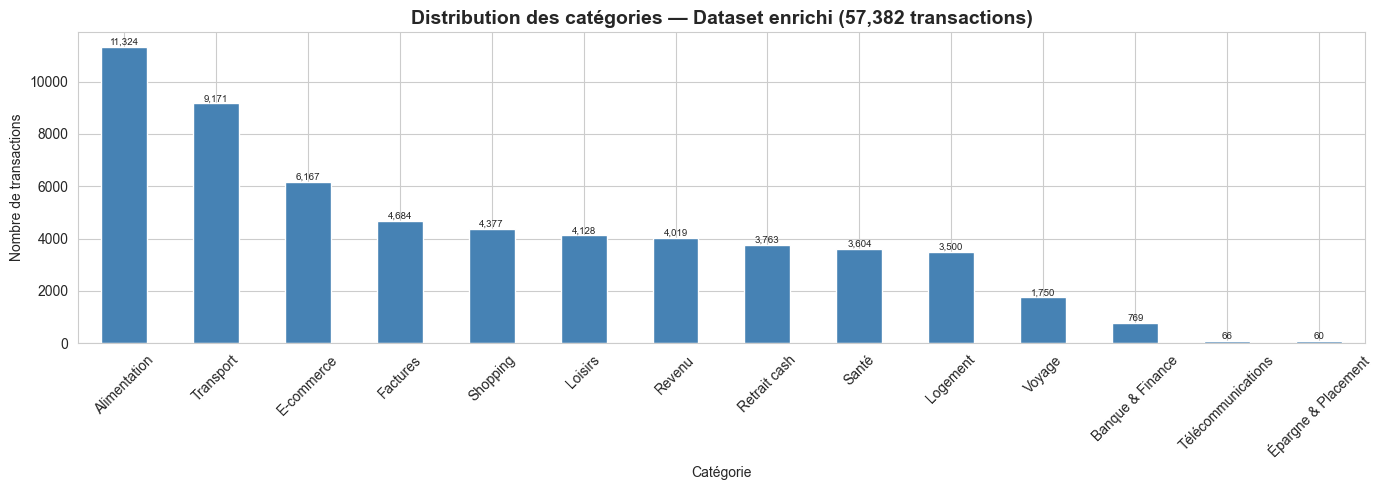


Nouvelles catégories vs dataset original:
  Originales (11) : ['Alimentation', 'E-commerce', 'Factures', 'Logement', 'Loisirs', 'Retrait cash', 'Revenu', 'Santé', 'Shopping', 'Transport', 'Voyage']
  Nouvelles  (3)  : ['Banque & Finance', 'Télécommunications', 'Épargne & Placement']


In [3]:
cat_counts = df['category'].value_counts()

fig, ax = plt.subplots(figsize=(14, 5))
cat_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title(f'Distribution des catégories — Dataset enrichi ({len(df):,} transactions)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Catégorie')
ax.set_ylabel('Nombre de transactions')
ax.tick_params(axis='x', rotation=45)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=7)
plt.tight_layout()
plt.savefig(MODELS_STORE / 'category_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

print(f'\nNouvelles catégories vs dataset original:')
original_cats = {'Alimentation','E-commerce','Factures','Logement','Loisirs',
                 'Retrait cash','Revenu','Santé','Shopping','Transport','Voyage'}
new_cats = set(df['category'].unique()) - original_cats
print(f'  Originales ({len(original_cats)}) : {sorted(original_cats)}')
print(f'  Nouvelles  ({len(new_cats)})  : {sorted(new_cats)}')

## 2. Préparation de la feature textuelle

On utilise `text_to_segment` (déjà disponible dans le CSV) = `clean_merchant_name + ' ' + clean_narration`  
Tout en minuscules, pré-nettoyé. C'est la feature d'entrée du TF-IDF.

In [4]:
# Vérification de la feature text_to_segment
# Format : clean_merchant_name.lower() + ' ' + clean_narration.lower()
print(f'Lignes prêtes pour la vectorisation : {len(df):,}')
print(f'\nExemples de textes par catégorie :')
for cat in sorted(df["category"].unique()):
    sample = df[df["category"] == cat]["text_to_segment"].iloc[0]
    print(f'  [{cat:<25s}] -> "{sample}"')

Lignes prêtes pour la vectorisation : 57,382

Exemples de textes par catégorie :
  [Alimentation             ] -> "carrefour paiement carrefour rabat"
  [Banque & Finance         ] -> "atm retrait atm"
  [E-commerce               ] -> "jumia jumia maroc"
  [Factures                 ] -> "orange orange mobile"
  [Logement                 ] -> "loyer appartement loyer appartement rabat"
  [Loisirs                  ] -> "cinéma megarama megarama rabat"
  [Retrait cash             ] -> "atm retrait gab tanger"
  [Revenu                   ] -> "salaire virement employeur"
  [Santé                    ] -> "clinique atlas paiement clinique"
  [Shopping                 ] -> "zara zara"
  [Transport                ] -> "careem transport careem rabat"
  [Télécommunications       ] -> "maroc telecom retrait"
  [Voyage                   ] -> "booking booking hotel"
  [Épargne & Placement      ] -> "épargne cih virement epargne"


In [5]:
X = df['text_to_segment']
y = df['category']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f'Train: {len(X_train):,} | Test: {len(X_test):,}')
print(f'Catégories train: {y_train.nunique()} | Catégories test: {y_test.nunique()}')

Train: 45,905 | Test: 11,477
Catégories train: 14 | Catégories test: 14


## 3. Vectorisation TF-IDF + Entraînement Régression Logistique

In [6]:
vectorizer = TfidfVectorizer(
    max_features=10_000,      # augmenté pour couvrir le vocabulaire enrichi
    ngram_range=(1, 2),
    sublinear_tf=True,
    strip_accents='unicode',
    analyzer='word',
    token_pattern=r'(?u)\b\w+\b',
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf  = vectorizer.transform(X_test)

print(f'Matrice TF-IDF train : {X_train_tfidf.shape}')
print(f'Vocabulaire          : {len(vectorizer.vocabulary_):,} termes')

Matrice TF-IDF train : (45905, 699)
Vocabulaire          : 699 termes


In [7]:
classifier = LogisticRegression(
    max_iter=1000,
    C=5.0,              # régularisation plus souple pour le vocabulaire enrichi
    random_state=42,
    class_weight='balanced',
    solver='lbfgs',
)

classifier.fit(X_train_tfidf, y_train)
print('Modèle entraîné.')
print(f'Classes ({len(classifier.classes_)}) : {list(classifier.classes_)}')

Modèle entraîné.
Classes (14) : ['Alimentation', 'Banque & Finance', 'E-commerce', 'Factures', 'Logement', 'Loisirs', 'Retrait cash', 'Revenu', 'Santé', 'Shopping', 'Transport', 'Télécommunications', 'Voyage', 'Épargne & Placement']


## 4. Évaluation

In [8]:
y_pred = classifier.predict(X_test_tfidf)

acc  = accuracy_score(y_test, y_pred)
f1_w = f1_score(y_test, y_pred, average='weighted')
f1_m = f1_score(y_test, y_pred, average='macro')

print(f'Accuracy         : {acc:.4f} ({acc*100:.2f}%)')
print(f'F1 (weighted)    : {f1_w:.4f}')
print(f'F1 (macro)       : {f1_m:.4f}')
print()
print(classification_report(y_test, y_pred, digits=4))

Accuracy         : 0.9963 (99.63%)
F1 (weighted)    : 0.9963
F1 (macro)       : 0.9954

                     precision    recall  f1-score   support

       Alimentation     1.0000    1.0000    1.0000      2265
   Banque & Finance     1.0000    0.9675    0.9835       154
         E-commerce     1.0000    1.0000    1.0000      1233
           Factures     1.0000    1.0000    1.0000       937
           Logement     1.0000    1.0000    1.0000       700
            Loisirs     1.0000    1.0000    1.0000       826
       Retrait cash     0.9934    1.0000    0.9967       753
             Revenu     1.0000    0.9540    0.9764       804
              Santé     1.0000    1.0000    1.0000       721
           Shopping     0.9594    1.0000    0.9793       875
          Transport     1.0000    1.0000    1.0000      1834
 Télécommunications     1.0000    1.0000    1.0000        13
             Voyage     1.0000    1.0000    1.0000       350
Épargne & Placement     1.0000    1.0000    1.0000       

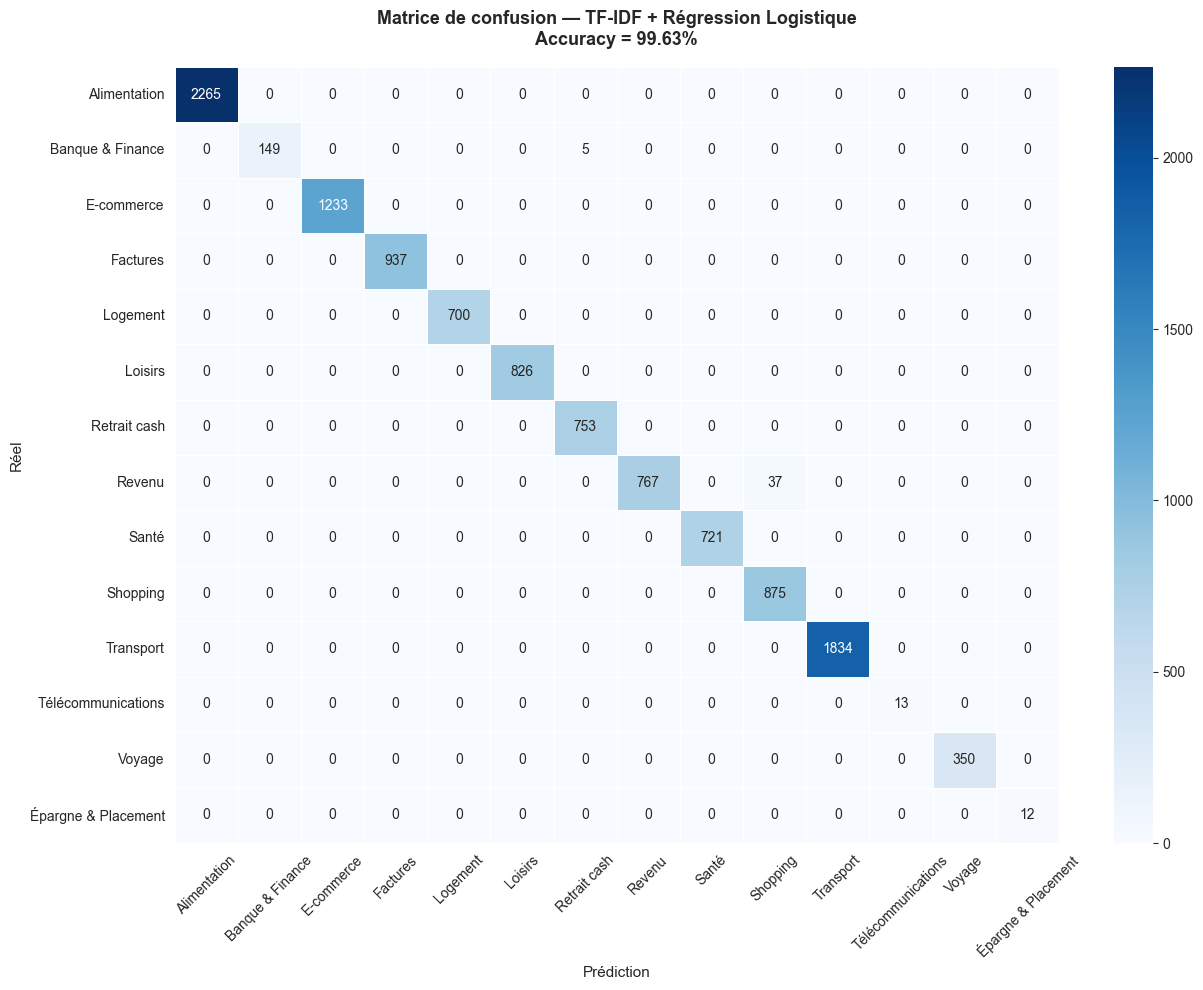

In [9]:
# Matrice de confusion
labels = list(classifier.classes_)
cm = confusion_matrix(y_test, y_pred, labels=labels)

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=labels, yticklabels=labels,
    linewidths=0.5, ax=ax
)
ax.set_title(f'Matrice de confusion — TF-IDF + Régression Logistique\nAccuracy = {acc*100:.2f}%',
             fontsize=13, fontweight='bold', pad=16)
ax.set_xlabel('Prédiction', fontsize=11)
ax.set_ylabel('Réel', fontsize=11)
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.savefig(MODELS_STORE / 'confusion_matrix_classification.png', dpi=100, bbox_inches='tight')
plt.show()

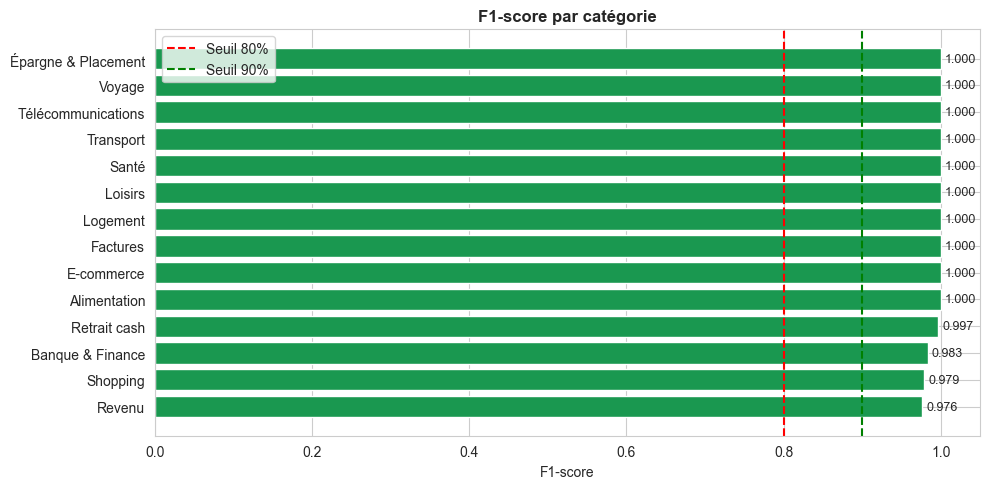

In [10]:
# F1 par catégorie
from sklearn.metrics import f1_score
f1_per_class = f1_score(y_test, y_pred, labels=labels, average=None)
f1_df = pd.DataFrame({'category': labels, 'f1': f1_per_class}).sort_values('f1')

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#d73027' if f < 0.8 else '#fee090' if f < 0.9 else '#1a9850' for f in f1_df['f1']]
ax.barh(f1_df['category'], f1_df['f1'], color=colors, edgecolor='white')
ax.axvline(0.8, color='red', linestyle='--', linewidth=1.5, label='Seuil 80%')
ax.axvline(0.9, color='green', linestyle='--', linewidth=1.5, label='Seuil 90%')
ax.set_xlabel('F1-score')
ax.set_title('F1-score par catégorie', fontweight='bold')
ax.legend()
for i, (_, row) in enumerate(f1_df.iterrows()):
    ax.text(row['f1'] + 0.005, i, f"{row['f1']:.3f}", va='center', fontsize=9)
plt.tight_layout()
plt.savefig(MODELS_STORE / 'f1_per_category.png', dpi=100, bbox_inches='tight')
plt.show()

## 5. Features les plus importantes par catégorie

Les coefficients de la Régression Logistique révèlent quels mots/bigrammes  
sont les plus discriminants pour chaque catégorie.

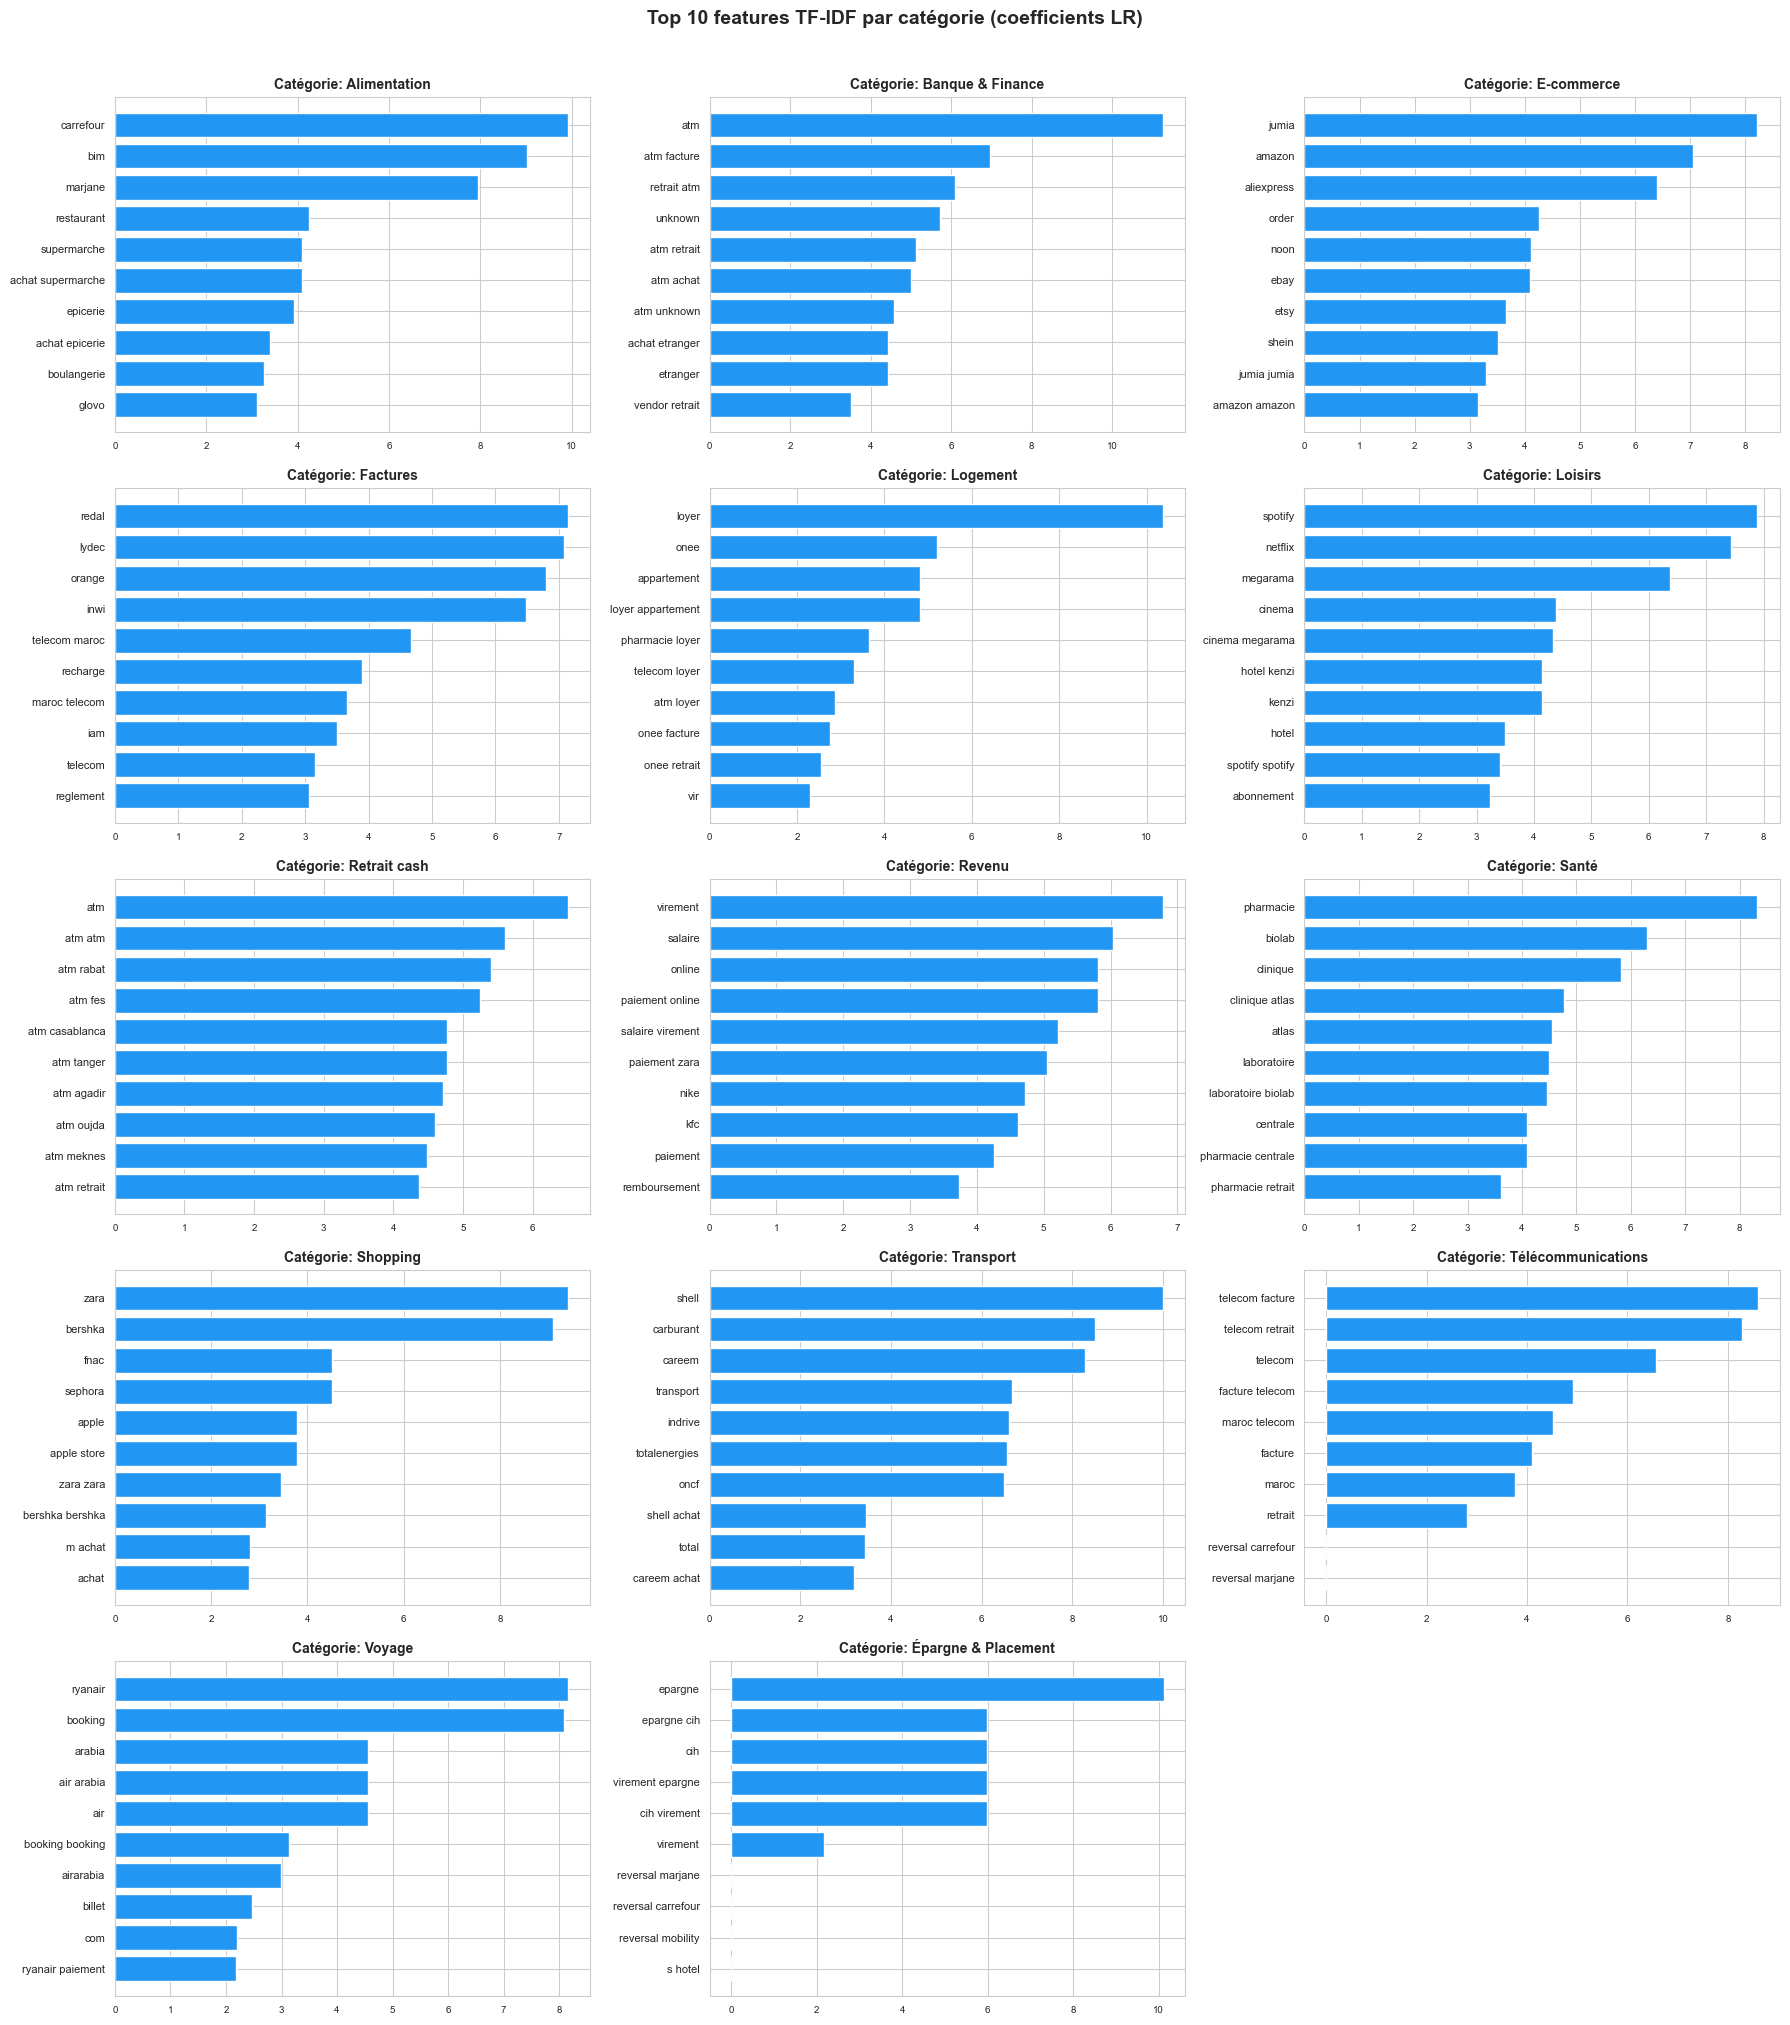

In [11]:
feature_names = np.array(vectorizer.get_feature_names_out())
n_cats = len(classifier.classes_)
ncols = 3
nrows = (n_cats + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 4))
axes = axes.flatten()

for i, (cat, coef) in enumerate(zip(classifier.classes_, classifier.coef_)):
    top_idx  = coef.argsort()[-10:][::-1]
    top_feat = feature_names[top_idx]
    top_vals = coef[top_idx]
    ax = axes[i]
    colors_bar = ['#2196F3' if v > 0 else '#F44336' for v in top_vals]
    ax.barh(top_feat[::-1], top_vals[::-1], color=colors_bar[::-1], edgecolor='white')
    ax.set_title(f'Catégorie: {cat}', fontweight='bold', fontsize=10)
    ax.tick_params(axis='y', labelsize=8)
    ax.tick_params(axis='x', labelsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Top 10 features TF-IDF par catégorie (coefficients LR)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(MODELS_STORE / 'top_features_per_category.png', dpi=100, bbox_inches='tight')
plt.show()

## 6. Sauvegarde des modèles

In [12]:
vec_path = MODELS_STORE / 'tfidf_vectorizer.pkl'
clf_path = MODELS_STORE / 'lr_category_classifier.pkl'

joblib.dump(vectorizer, vec_path)
joblib.dump(classifier, clf_path)

print(f'Vectorizer sauvegarde -> {vec_path}')
print(f'Classifier sauvegarde -> {clf_path}')
print()

# Verification avec le pipeline complet (regles + ML)
# En production : regles d'abord sur les marchands connus,
# ML uniquement pour les textes non couverts par les regles.
import sys
sys.path.insert(0, str(PROJECT_ROOT / 'backend'))

import pipeline.categorization.classifier as _clf_mod
_clf_mod._vectorizer = None   # force rechargement des pkl
_clf_mod._classifier = None
from pipeline.categorization.classifier import classify as _classify

test_cases = [
    # narration               merchant     categorie_attendue
    ('careem transport',      'careem',    'Transport'),
    ('supermarche achat',     'carrefour', 'Alimentation'),
    ('virement employeur',    'salaire',   'Revenu'),
    ('loyer appartement',     'loyer',     'Logement'),
    ('medicament sante',      'pharmacie', 'Sante'),
    ('achat mode hm',         'H&M',       'Shopping'),
    ('achat sport',           'Nike',      'Shopping'),
    ('vetements mode',        'Zara',      'Shopping'),
    ('commande livraison',    'Amazon',    'E-commerce'),
    ('marketplace achat',     'Jumia',     'E-commerce'),
    ('cosmetique parfum',     'Sephora',   'Shopping'),
    ('informatique achat',    'Fnac',      'Shopping'),
]

_rows = pd.DataFrame([
    {'clean_narration': nar, 'clean_merchant_name': merch}
    for nar, merch, _ in test_cases
])
_result = _classify(_rows)

print('Verification pipeline complet (regles + ML) :')
print(f'  {"Marchand":<12} {"Attendu":<15} {"Obtenu":<15} {"Conf":>5}  Statut')
print(f'  {"-"*62}')
ok_count = 0
for (nar, merch, expected), (_, row) in zip(test_cases, _result.iterrows()):
    got  = row['category']
    conf = row['category_confidence']
    # Normalise accent for comparison (Sante vs Sante)
    ok   = got.replace('\xe9', 'e') == expected.replace('\xe9', 'e')
    ok_count += ok
    print(f'  {merch:<12} {expected:<15} {got:<15} {conf:>4.0%}  {"OK" if ok else "ERREUR"}')

print(f'\nScore verification : {ok_count}/{len(test_cases)} ({ok_count/len(test_cases)*100:.0f}%)')
print(f'Accuracy modele sur test set : {acc*100:.2f}%')

Vectorizer sauvegarde -> C:\Users\oumai\Downloads\PE\PE\backend\models_store\tfidf_vectorizer.pkl
Classifier sauvegarde -> C:\Users\oumai\Downloads\PE\PE\backend\models_store\lr_category_classifier.pkl

Verification pipeline complet (regles + ML) :
  Marchand     Attendu         Obtenu           Conf  Statut
  --------------------------------------------------------------
  careem       Transport       Transport       100%  OK
  carrefour    Alimentation    Alimentation    100%  OK
  salaire      Revenu          Revenu          100%  OK
  loyer        Logement        Logement        100%  OK
  pharmacie    Sante           Santé           100%  OK
  H&M          Shopping        Shopping        100%  OK
  Nike         Shopping        Shopping        100%  OK
  Zara         Shopping        Shopping        100%  OK
  Amazon       E-commerce      E-commerce      100%  OK
  Jumia        E-commerce      E-commerce      100%  OK
  Sephora      Shopping        Shopping        100%  OK
  Fnac   